# 04 — Grouped versus full 19-class nested spatial modelling and SHAP

This notebook implements a controlled comparison of two semantic representations under the **same frozen five-fold spatial design**.

## Experiment A — grouped semantic representation

- Logistic regression: **7 grouped indicators + zero replacement + CLR**
- Random Forest: **7 grouped indicators on the raw closed scale**
- XGBoost: **7 grouped indicators on the raw closed scale**

## Experiment B — full semantic representation

- Logistic regression: **19 semantic classes + zero replacement + ILR**
- Random Forest: **19 semantic classes on the raw closed scale**
- XGBoost: **19 semantic classes on the raw closed scale**

## Methodological boundary

- One observation per LSOA; expected sample size: **488 Leeds LSOAs**.
- The existing fold map is immutable. No folds are generated, shuffled or repaired here.
- Hyperparameter tuning occurs only inside each outer-training partition.
- Every candidate produces one out-of-fold prediction for every LSOA.
- Macro-F1 is the primary selection metric; balanced accuracy, log-loss and multiclass Brier score are supporting metrics.
- SHAP is applied only after model selection and full-data spatial tuning.
- Moran's I and LISA remain in Notebook 05.


## 1. Colab setup and package installation

In [1]:
from google.colab import drive
drive.mount("/content/drive")

In [2]:
!pip -q install scikit-learn xgboost shap matplotlib openpyxl joblib

## 2. Configuration

In [3]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paths shared with Notebooks 01–03.
PROJECT_DIR = Path("/content/drive/MyDrive/leeds_gsv_project")
OUTPUT_DIR = PROJECT_DIR / "outputs_10points_metadata_once"
QA_DIR = OUTPUT_DIR / "dataset_quality_assurance"
MODELLING_DIR = OUTPUT_DIR / "nested_spatial_modelling_grouped_vs_full19"
MODEL_DIR = MODELLING_DIR / "models"
FIGURE_DIR = MODELLING_DIR / "figures"
for folder in (MODELLING_DIR, MODEL_DIR, FIGURE_DIR):
    folder.mkdir(parents=True, exist_ok=True)

# Frozen inputs.
LSOA_FEATURE_FILE = OUTPUT_DIR / "segmentation_lsoa_features_19class_mean_sd.csv"
FOLD_MAP_FILE = OUTPUT_DIR / "lsoa_spatial_plus_fold_mapping.csv"
FOLD_AUDIT_FILE = OUTPUT_DIR / "spatial_plus_fold_audit.csv"
FOLD_FEATURE_BALANCE_FILE = OUTPUT_DIR / "spatial_plus_fold_feature_balance.csv"
QA_DECISION_FILE = QA_DIR / "qa_final_decision.json"

LSOA_ID_COL = "LSOA21CD"
TARGET_DECILE_COL = "IMDDecile"
TARGET_CLASS_COL = "DeprivationClass"
CLASS_INDEX_COL = "ClassIdx"
FOLD_COL = "spatial_fold"
BLOCK_COL = "spatial_block"
CLASS_ORDER = ["High Deprivation", "Medium Deprivation", "Low Deprivation"]
CLASS_TO_IDX = {label: idx for idx, label in enumerate(CLASS_ORDER)}
EXPECTED_N_ROWS = 488
EXPECTED_FOLDS = {1, 2, 3, 4, 5}

GROUPED_FEATURES = [
    "green_natural_mean",
    "built_form_mean",
    "pedestrian_realm_mean",
    "road_transport_mean",
    "street_furniture_mean",
    "active_travel_people_mean",
    "sky_openness_mean",
]

RAW19_FEATURES_OVERRIDE = None
N_JOBS = -1

OUTER_METRICS_CSV = MODELLING_DIR / "nested_spatial_outer_fold_metrics.csv"
OOF_ALL_MODELS_CSV = MODELLING_DIR / "nested_spatial_oof_predictions_all_models.csv"
OOF_SELECTED_DIAGNOSTICS_CSV = MODELLING_DIR / "selected_model_oof_spatial_diagnostics.csv"
INNER_CV_RESULTS_CSV = MODELLING_DIR / "nested_spatial_inner_grid_results.csv"
MODEL_COMPARISON_CSV = MODELLING_DIR / "nested_spatial_model_comparison.csv"
FINAL_TUNING_CSV = MODELLING_DIR / "final_full_data_tuning_results.csv"
FINAL_MODEL_FILE = MODEL_DIR / "final_selected_model.joblib"
FINAL_METADATA_JSON = MODEL_DIR / "final_selected_model_metadata.json"
CONFUSION_MATRIX_PNG = FIGURE_DIR / "selected_model_oof_confusion_matrix.png"
SHAP_IMPORTANCE_CSV = MODELLING_DIR / "final_shap_global_importance.csv"
SHAP_TOP20_PNG = FIGURE_DIR / "final_shap_top20.png"

print("Production output directory:", OUTPUT_DIR)
print("Modelling output directory:", MODELLING_DIR)

## 3. Imports and helper functions

In [4]:
import matplotlib.pyplot as plt
import joblib
import shap
from scipy.linalg import helmert

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    log_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from xgboost import XGBClassifier




def classify_deprivation_decile(value):
    if pd.isna(value):
        return np.nan
    decile = int(value)
    if not 1 <= decile <= 10:
        raise ValueError(f"IMD decile must be in 1..10; found {value!r}")
    if decile <= 3:
        return "High Deprivation"
    if decile <= 7:
        return "Medium Deprivation"
    return "Low Deprivation"


class MultiplicativeZeroReplacementCLR(BaseEstimator, TransformerMixin):
    """Zero replacement followed by CLR, fitted without using outcome data.

    The replacement is row-specific and preserves closure. This transformer is
    intentionally inside the sklearn Pipeline so it is applied separately within
    every inner and outer training partition.
    """

    def __init__(self, delta=1e-6, closure_tolerance=5e-3):
        self.delta = delta
        self.closure_tolerance = closure_tolerance

    def fit(self, X, y=None):
        X = self._validate(X)
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        X = self._validate(X)
        if hasattr(self, "n_features_in_") and X.shape[1] != self.n_features_in_:
            raise ValueError("Feature count differs from the fitted composition.")
        X = self._close(X)
        X = self._replace_zeros(X)
        log_x = np.log(X)
        return log_x - log_x.mean(axis=1, keepdims=True)

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.asarray([f"clr_{i}" for i in range(self.n_features_in_)], dtype=object)
        return np.asarray([f"clr_{name}" for name in input_features], dtype=object)

    def _validate(self, X):
        X = np.asarray(X, dtype=float)
        if X.ndim != 2:
            raise ValueError("Compositional input must be a two-dimensional matrix.")
        if not np.isfinite(X).all():
            raise ValueError("Compositional input contains NaN or infinite values.")
        if (X < 0).any():
            raise ValueError("Compositional input contains negative values.")
        if (X.sum(axis=1) <= 0).any():
            raise ValueError("At least one composition has a non-positive row sum.")
        return X

    @staticmethod
    def _close(X):
        return X / X.sum(axis=1, keepdims=True)

    def _replace_zeros(self, X):
        out = X.copy()
        for i, row in enumerate(out):
            zero_mask = row <= 0
            n_zero = int(zero_mask.sum())
            if n_zero == 0:
                continue
            positive_mask = ~zero_mask
            # Keep total replacement mass small enough for every observed row.
            replacement = min(self.delta, 0.5 / max(n_zero, 1))
            replacement_mass = replacement * n_zero
            if not positive_mask.any() or replacement_mass >= 1:
                raise ValueError("Zero replacement failed for a degenerate composition.")
            row[zero_mask] = replacement
            row[positive_mask] *= (1.0 - replacement_mass) / row[positive_mask].sum()
            out[i] = row
        return self._close(out)



class MultiplicativeZeroReplacementILR(MultiplicativeZeroReplacementCLR):
    """Multiplicative zero replacement followed by an orthonormal ILR transform."""

    def fit(self, X, y=None):
        X = self._validate(X)
        self.n_features_in_ = X.shape[1]
        if self.n_features_in_ < 2:
            raise ValueError("ILR requires at least two compositional parts.")
        # helmert(D, full=False) is (D-1) x D; transpose gives D x (D-1).
        self.ilr_basis_ = helmert(self.n_features_in_, full=False).T
        gram = self.ilr_basis_.T @ self.ilr_basis_
        if not np.allclose(gram, np.eye(self.n_features_in_ - 1), atol=1e-10):
            raise AssertionError("The ILR basis is not orthonormal.")
        return self

    def transform(self, X):
        X = self._validate(X)
        if X.shape[1] != self.n_features_in_:
            raise ValueError("The number of compositional parts changed after fitting.")
        X = self._close(X)
        X = self._replace_zeros(X)
        return np.log(X) @ self.ilr_basis_

    def get_feature_names_out(self, input_features=None):
        return np.asarray(
            [f"ilr_balance_{i:02d}" for i in range(1, self.n_features_in_)],
            dtype=object,
        )


def normalise_probabilities(prob):
    """Clip floating-point drift and force each probability row to sum to one."""
    prob = np.asarray(prob, dtype=float)
    if prob.ndim != 2:
        raise ValueError(f"predict_proba returned shape {prob.shape}; expected 2D.")
    if not np.isfinite(prob).all():
        raise ValueError("Predicted probabilities contain NaN or infinity.")
    prob = np.clip(prob, 0.0, 1.0)
    row_sum = prob.sum(axis=1, keepdims=True)
    if (row_sum <= 0).any():
        raise ValueError("At least one probability row has zero total mass.")
    prob = prob / row_sum
    if not np.allclose(prob.sum(axis=1), 1.0, atol=1e-10):
        raise AssertionError("Probability normalisation failed.")
    return prob


def discover_raw19_features(frame):
    if RAW19_FEATURES_OVERRIDE is not None:
        selected = list(RAW19_FEATURES_OVERRIDE)
        missing = sorted(set(selected).difference(frame.columns))
        if missing:
            raise KeyError(f"RAW19_FEATURES_OVERRIDE contains missing columns: {missing}")
        if len(selected) != 19:
            raise ValueError(
                f"RAW19_FEATURES_OVERRIDE must contain exactly 19 columns; got {len(selected)}."
            )
        return selected

    candidates = [
        c for c in frame.columns
        if c.startswith("seg_")
        and c.endswith("_mean")
        and pd.api.types.is_numeric_dtype(frame[c])
        and c not in GROUPED_FEATURES
    ]
    candidates = sorted(candidates)
    if len(candidates) != 19:
        available = sorted(
            c for c in frame.columns
            if c.endswith("_mean")
            and c not in GROUPED_FEATURES
            and pd.api.types.is_numeric_dtype(frame[c])
        )
        raise ValueError(
            "Expected exactly 19 raw semantic mean columns beginning with 'seg_'; "
            f"found {len(candidates)}. Set RAW19_FEATURES_OVERRIDE to the exact 19 columns. "
            f"Available numeric *_mean columns: {available}"
        )
    return candidates


def metric_row(y_true, y_pred, y_prob, model_name, outer_fold, best_params):
    return {
        "model": model_name,
        "outer_fold": outer_fold,
        "n_test": len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "log_loss": log_loss(y_true, y_prob, labels=np.arange(len(CLASS_ORDER))),
        "multiclass_brier": np.mean(
            np.sum((np.eye(len(CLASS_ORDER))[np.asarray(y_true, dtype=int)] - y_prob) ** 2, axis=1)
        ),
        "best_params": json.dumps(best_params, sort_keys=True),
    }

## 4. Load the LSOA feature table and frozen fold map

In [5]:
required_files = [
    LSOA_FEATURE_FILE,
    FOLD_MAP_FILE,
    FOLD_AUDIT_FILE,
    FOLD_FEATURE_BALANCE_FILE,
]
missing = [str(path) for path in required_files if not path.exists()]
if missing:
    raise FileNotFoundError("Required production files are missing:\n- " + "\n- ".join(missing))

df = pd.read_csv(LSOA_FEATURE_FILE)
fold_map = pd.read_csv(FOLD_MAP_FILE)
fold_audit = pd.read_csv(FOLD_AUDIT_FILE)
fold_feature_balance = pd.read_csv(FOLD_FEATURE_BALANCE_FILE)

print("Loaded feature table:", LSOA_FEATURE_FILE)
print("Feature-table shape:", df.shape)
print("Loaded frozen fold map:", FOLD_MAP_FILE)
print("Fold-map shape:", fold_map.shape)

required_fold_cols = {LSOA_ID_COL, BLOCK_COL, FOLD_COL}
if not required_fold_cols.issubset(fold_map.columns):
    raise KeyError(f"Frozen fold map must contain {sorted(required_fold_cols)}")
if fold_map[LSOA_ID_COL].duplicated().any():
    raise ValueError("Frozen fold map contains duplicate LSOA identifiers.")

# The exported fold map is authoritative; embedded assignments must match it.
if FOLD_COL in df.columns:
    check = df[[LSOA_ID_COL, FOLD_COL]].merge(
        fold_map[[LSOA_ID_COL, FOLD_COL]], on=LSOA_ID_COL,
        suffixes=("_feature", "_frozen"), validate="one_to_one"
    )
    mismatch = check[FOLD_COL + "_feature"].astype(int) != check[FOLD_COL + "_frozen"].astype(int)
    if mismatch.any():
        raise ValueError("Feature-table fold assignments disagree with the frozen fold map.")

df = df.drop(columns=[FOLD_COL, BLOCK_COL], errors="ignore").merge(
    fold_map[[LSOA_ID_COL, BLOCK_COL, FOLD_COL]],
    on=LSOA_ID_COL, how="left", validate="one_to_one"
)

# Reconstruct the frozen targets only as an integrity check.
required_targets = {TARGET_DECILE_COL, TARGET_CLASS_COL, CLASS_INDEX_COL}
if not required_targets.issubset(df.columns):
    raise KeyError(f"Feature table is missing target columns: {sorted(required_targets.difference(df.columns))}")

reconstructed_class = df[TARGET_DECILE_COL].apply(classify_deprivation_decile)
if not reconstructed_class.equals(df[TARGET_CLASS_COL]):
    raise ValueError("Stored deprivation classes disagree with IMDDecile classification rules.")
if not df[TARGET_CLASS_COL].map(CLASS_TO_IDX).astype(int).equals(df[CLASS_INDEX_COL].astype(int)):
    raise ValueError("Stored ClassIdx values disagree with the declared class order.")

## 5. Quality, leakage and fold-integrity checks

In [6]:
problems = []

if len(df) != EXPECTED_N_ROWS:
    problems.append(f"Expected {EXPECTED_N_ROWS} LSOAs but found {len(df)}.")
if df[LSOA_ID_COL].isna().any():
    problems.append("Missing LSOA identifiers.")
if df[LSOA_ID_COL].duplicated().any():
    problems.append("Duplicate LSOA identifiers.")
if df[FOLD_COL].isna().any():
    problems.append("Missing frozen spatial-fold assignments.")
if set(pd.to_numeric(df[FOLD_COL], errors="coerce").dropna().astype(int).unique()) != EXPECTED_FOLDS:
    problems.append(
        f"Expected frozen folds {sorted(EXPECTED_FOLDS)} but found "
        f"{sorted(df[FOLD_COL].dropna().unique().tolist())}."
    )
if df[CLASS_INDEX_COL].isna().any():
    problems.append("Target construction produced missing class labels.")
if not set(GROUPED_FEATURES).issubset(df.columns):
    problems.append(
        "Grouped semantic indicators are missing: "
        + ", ".join(sorted(set(GROUPED_FEATURES).difference(df.columns)))
    )

if problems:
    raise ValueError("Dataset/fold integrity checks failed:\n- " + "\n- ".join(problems))

df[FOLD_COL] = df[FOLD_COL].astype(int)
df[CLASS_INDEX_COL] = df[CLASS_INDEX_COL].astype(int)

grouped = df[GROUPED_FEATURES].apply(pd.to_numeric, errors="coerce")
if grouped.isna().any().any():
    bad = grouped.columns[grouped.isna().any()].tolist()
    raise ValueError(f"Grouped features contain missing/non-numeric values: {bad}")
if (~np.isfinite(grouped.to_numpy())).any():
    raise ValueError("Grouped features contain infinite values.")
if (grouped < 0).any().any():
    raise ValueError("Grouped compositional features contain negative values.")

composition_sum = grouped.sum(axis=1)
composition_summary = composition_sum.describe()
display(composition_summary.to_frame("grouped_sum"))
if not np.allclose(composition_sum, 1.0, atol=5e-3):
    raise ValueError(
        "Grouped indicators do not close to approximately one. Review Notebook 02 "
        "before modelling rather than forcing a compositional transform."
    )

# Block target leakage.
forbidden_tokens = ("imd", "deprivation", "target", "classidx", "rank", "decile")
leaking_features = [
    c for c in GROUPED_FEATURES
    if any(token in c.lower() for token in forbidden_tokens)
]
if leaking_features:
    raise ValueError(f"Potential target-derived predictors detected: {leaking_features}")

class_by_fold = pd.crosstab(df[FOLD_COL], df[TARGET_CLASS_COL]).reindex(
    index=sorted(EXPECTED_FOLDS), columns=CLASS_ORDER, fill_value=0
)
display(class_by_fold)
if (class_by_fold == 0).any().any():
    print(
        "WARNING: At least one outer spatial fold lacks a class. Macro metrics remain "
        "reported, but fold-specific estimates should be interpreted cautiously."
    )

print("Quality checks passed.")
print("The fold-map shape may contain many columns elsewhere; only the five unique values")
print("in spatial_fold determine the number of spatial folds.")

       grouped_sum
count   488.000000
mean      1.000111
std       0.000179
min       1.000000
25%       1.000015
50%       1.000048
75%       1.000125
max       1.001477

DeprivationClass  High Deprivation  Medium Deprivation  Low Deprivation
spatial_fold                                                           
1                               34                  30               34
2                               35                  29               34
3                               37                  29               33
4                               35                  28               33
5                               35                  29               33

Quality checks passed.
The fold-map shape may contain many columns elsewhere; only the five unique values
in spatial_fold determine the number of spatial folds.


## 6. Candidate models and model-specific compositional handling

In [7]:
X_grouped = df[GROUPED_FEATURES].copy()
y = df[CLASS_INDEX_COL].copy()
outer_groups = df[FOLD_COL].copy()

raw19_features = discover_raw19_features(df)

# Validate the 19-part composition before modelling.
raw19 = df[raw19_features].apply(pd.to_numeric, errors="coerce")
if raw19.isna().any().any():
    bad = raw19.columns[raw19.isna().any()].tolist()
    raise ValueError(f"Raw 19-class features contain missing/non-numeric values: {bad}")
if (~np.isfinite(raw19.to_numpy())).any():
    raise ValueError("Raw 19-class features contain infinite values.")
if (raw19 < 0).any().any():
    raise ValueError("Raw 19-class compositional features contain negative values.")
raw19_sum = raw19.sum(axis=1)
display(raw19_sum.describe().to_frame("raw19_sum"))
if not np.allclose(raw19_sum, 1.0, atol=5e-3):
    raise ValueError(
        "The 19 semantic means do not close to approximately one. "
        "Correct the upstream feature table rather than forcing closure here."
    )

logistic_grid = {
    "clf__C": [0.01, 0.1, 1.0, 10.0],
    "clf__class_weight": [None, "balanced"],
}

rf_grid = {
    "clf__n_estimators": [300, 600],
    "clf__max_depth": [None, 5, 10],
    "clf__min_samples_leaf": [2, 5, 10],
    "clf__max_features": ["sqrt", 0.7],
    "clf__class_weight": [None, "balanced"],
}

xgb_grid = {
    "clf__n_estimators": [200, 400],
    "clf__learning_rate": [0.03, 0.08],
    "clf__max_depth": [2, 3],
    "clf__min_child_weight": [1, 5],
    "clf__subsample": [0.8],
    "clf__colsample_bytree": [0.8],
    "clf__reg_lambda": [1.0, 5.0],
}

def make_logistic(transformer_name, transformer):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        (transformer_name, transformer),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=10000,
            random_state=RANDOM_STATE,
        )),
    ])

def make_rf():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
        )),
    ])

def make_xgb():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", XGBClassifier(
            objective="multi:softprob",
            num_class=len(CLASS_ORDER),
            eval_metric="mlogloss",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
            verbosity=0,
        )),
    ])

candidates = {
    "logistic_grouped_clr": {
        "experiment": "grouped_7",
        "algorithm": "Logistic Regression",
        "features": GROUPED_FEATURES,
        "pipeline": make_logistic(
            "clr", MultiplicativeZeroReplacementCLR(delta=1e-6)
        ),
        "grid": logistic_grid,
        "representation": "seven grouped means; zero replacement + CLR",
    },
    "random_forest_grouped_raw": {
        "experiment": "grouped_7",
        "algorithm": "Random Forest",
        "features": GROUPED_FEATURES,
        "pipeline": make_rf(),
        "grid": rf_grid,
        "representation": "seven grouped means retained on raw closed scale",
    },
    "xgboost_grouped_raw": {
        "experiment": "grouped_7",
        "algorithm": "XGBoost",
        "features": GROUPED_FEATURES,
        "pipeline": make_xgb(),
        "grid": xgb_grid,
        "representation": "seven grouped means retained on raw closed scale",
    },
    "logistic_full19_ilr": {
        "experiment": "full_19",
        "algorithm": "Logistic Regression",
        "features": raw19_features,
        "pipeline": make_logistic(
            "ilr", MultiplicativeZeroReplacementILR(delta=1e-6)
        ),
        "grid": logistic_grid,
        "representation": "19 semantic means; zero replacement + ILR",
    },
    "random_forest_full19_raw": {
        "experiment": "full_19",
        "algorithm": "Random Forest",
        "features": raw19_features,
        "pipeline": make_rf(),
        "grid": rf_grid,
        "representation": "19 semantic means retained on raw closed scale",
    },
    "xgboost_full19_raw": {
        "experiment": "full_19",
        "algorithm": "XGBoost",
        "features": raw19_features,
        "pipeline": make_xgb(),
        "grid": xgb_grid,
        "representation": "19 semantic means retained on raw closed scale",
    },
}

candidate_manifest = pd.DataFrame([
    {
        "model": name,
        "experiment": spec["experiment"],
        "algorithm": spec["algorithm"],
        "n_input_features": len(spec["features"]),
        "representation": spec["representation"],
    }
    for name, spec in candidates.items()
])
display(candidate_manifest)
candidate_manifest.to_csv(MODELLING_DIR / "candidate_model_manifest.csv", index=False)


          raw19_sum
count  4.880000e+02
mean   1.000000e+00
std    3.863653e-16
min    1.000000e+00
25%    1.000000e+00
50%    1.000000e+00
75%    1.000000e+00
max    1.000000e+00

                       model experiment            algorithm  \
0       logistic_grouped_clr  grouped_7  Logistic Regression   
1  random_forest_grouped_raw  grouped_7        Random Forest   
2        xgboost_grouped_raw  grouped_7              XGBoost   
3        logistic_full19_ilr    full_19  Logistic Regression   
4   random_forest_full19_raw    full_19        Random Forest   
5         xgboost_full19_raw    full_19              XGBoost   

   n_input_features                                    representation  
0                 7       seven grouped means; zero replacement + CLR  
1                 7  seven grouped means retained on raw closed scale  
2                 7  seven grouped means retained on raw closed scale  
3                19         19 semantic means; zero replacement + ILR  
4                19    19 semantic means retained on raw closed scale  
5                19    19 semantic means retained on raw closed scale  

## 7. Nested five-fold spatial cross-validation

In [8]:
outer_metric_rows = []
oof_frames = []
inner_result_frames = []

for model_name, spec in candidates.items():
    feature_names = spec["features"]
    X_model = df[feature_names].copy()

    print("\n" + "=" * 80)
    print("Candidate:", model_name)
    print("Representation:", spec["representation"])

    for outer_fold in sorted(EXPECTED_FOLDS):
        train_mask = outer_groups != outer_fold
        test_mask = outer_groups == outer_fold

        X_train = X_model.loc[train_mask]
        X_test = X_model.loc[test_mask]
        y_train = y.loc[train_mask]
        y_test = y.loc[test_mask]
        inner_groups = outer_groups.loc[train_mask]

        if set(inner_groups.unique()) != EXPECTED_FOLDS.difference({outer_fold}):
            raise ValueError(f"Unexpected inner groups for outer fold {outer_fold}.")
        if set(df.loc[train_mask, LSOA_ID_COL]).intersection(
            set(df.loc[test_mask, LSOA_ID_COL])
        ):
            raise AssertionError("LSOA leakage between outer train and test partitions.")

        n_inner = inner_groups.nunique()
        if n_inner < 3:
            raise ValueError("Too few spatial groups for inner tuning.")
        inner_cv = GroupKFold(n_splits=n_inner)

        search = GridSearchCV(
            estimator=spec["pipeline"],
            param_grid=spec["grid"],
            scoring="f1_macro",
            cv=inner_cv,
            n_jobs=N_JOBS,
            refit=True,
            return_train_score=True,
            error_score="raise",
        )
        search.fit(X_train, y_train, groups=inner_groups)

        pred = search.predict(X_test)
        prob = normalise_probabilities(search.predict_proba(X_test))

        outer_metric_rows.append(
            metric_row(
                y_true=y_test,
                y_pred=pred,
                y_prob=prob,
                model_name=model_name,
                outer_fold=outer_fold,
                best_params=search.best_params_,
            )
        )

        fold_predictions = df.loc[
            test_mask,
            [LSOA_ID_COL, TARGET_DECILE_COL, TARGET_CLASS_COL, FOLD_COL],
        ].copy()
        fold_predictions["model"] = model_name
        fold_predictions["experiment"] = spec["experiment"]
        fold_predictions["algorithm"] = spec["algorithm"]
        fold_predictions["representation"] = spec["representation"]
        fold_predictions["observed_idx"] = y_test.to_numpy()
        fold_predictions["predicted_idx"] = pred
        fold_predictions["predicted_class"] = [
            CLASS_ORDER[int(i)] for i in pred
        ]
        fold_predictions["correct"] = (
            fold_predictions["observed_idx"] == fold_predictions["predicted_idx"]
        ).astype(int)
        # Match probability columns to the frozen class order.
        fitted_classes = search.best_estimator_.named_steps["clf"].classes_.astype(int)
        if not np.array_equal(fitted_classes, np.arange(len(CLASS_ORDER))):
            raise ValueError(f"Unexpected predict_proba class order: {fitted_classes}")

        observed_one_hot = np.eye(len(CLASS_ORDER))[y_test.to_numpy(dtype=int)]
        for class_idx, class_label in enumerate(CLASS_ORDER):
            safe_label = class_label.lower().replace(" ", "_")
            fold_predictions[f"prob_{safe_label}"] = prob[:, class_idx]
            # Class residual: I(y=k) - P(y=k).
            fold_predictions[f"resid_{safe_label}"] = observed_one_hot[:, class_idx] - prob[:, class_idx]

        observed_probability = prob[np.arange(len(prob)), y_test.to_numpy(dtype=int)]
        fold_predictions["binary_error"] = 1 - fold_predictions["correct"]
        fold_predictions["observed_class_probability"] = observed_probability
        fold_predictions["observed_probability_residual"] = 1.0 - observed_probability
        fold_predictions["individual_log_loss"] = -np.log(np.clip(observed_probability, 1e-15, 1.0))
        fold_predictions["multiclass_brier_contribution"] = np.sum(
            (observed_one_hot - prob) ** 2, axis=1
        )
        oof_frames.append(fold_predictions)

        inner_res = pd.DataFrame(search.cv_results_)
        inner_res["model"] = model_name
        inner_res["outer_fold"] = outer_fold
        inner_result_frames.append(inner_res)

        print(
            f"Outer fold {outer_fold}: n={len(y_test)}, "
            f"macro-F1={f1_score(y_test, pred, average='macro', zero_division=0):.3f}, "
            f"best inner macro-F1={search.best_score_:.3f}"
        )

outer_metrics = pd.DataFrame(outer_metric_rows)
oof_predictions = pd.concat(oof_frames, ignore_index=True)
inner_cv_results = pd.concat(inner_result_frames, ignore_index=True)

outer_metrics.to_csv(OUTER_METRICS_CSV, index=False)
oof_predictions.to_csv(OOF_ALL_MODELS_CSV, index=False)
inner_cv_results.to_csv(INNER_CV_RESULTS_CSV, index=False)

# Each candidate must predict every LSOA once out of fold.
coverage = oof_predictions.groupby("model")[LSOA_ID_COL].agg(["count", "nunique"])
display(coverage)
if not ((coverage["count"] == len(df)) & (coverage["nunique"] == len(df))).all():
    raise AssertionError("Out-of-fold prediction coverage is incomplete or duplicated.")

print("Saved:", OUTER_METRICS_CSV)
print("Saved:", OOF_ALL_MODELS_CSV)
print("Saved:", INNER_CV_RESULTS_CSV)


Candidate: logistic_grouped_clr
Representation: seven grouped means; zero replacement + CLR
Outer fold 1: n=98, macro-F1=0.384, best inner macro-F1=0.546
Outer fold 2: n=98, macro-F1=0.486, best inner macro-F1=0.504
Outer fold 3: n=99, macro-F1=0.468, best inner macro-F1=0.508
Outer fold 4: n=96, macro-F1=0.624, best inner macro-F1=0.429
Outer fold 5: n=97, macro-F1=0.508, best inner macro-F1=0.491

Candidate: random_forest_grouped_raw
Representation: seven grouped means retained on raw closed scale
Outer fold 1: n=98, macro-F1=0.431, best inner macro-F1=0.497
Outer fold 2: n=98, macro-F1=0.450, best inner macro-F1=0.496
Outer fold 3: n=99, macro-F1=0.457, best inner macro-F1=0.475
Outer fold 4: n=96, macro-F1=0.548, best inner macro-F1=0.437
Outer fold 5: n=97, macro-F1=0.425, best inner macro-F1=0.517

Candidate: xgboost_grouped_raw
Representation: seven grouped means retained on raw closed scale
Outer fold 1: n=98, macro-F1=0.389, best inner macro-F1=0.472
Outer fold 2: n=98, macro

                           count  nunique
model                                    
logistic_full19_ilr          488      488
logistic_grouped_clr         488      488
random_forest_full19_raw     488      488
random_forest_grouped_raw    488      488
xgboost_full19_raw           488      488
xgboost_grouped_raw          488      488

Saved: <PROJECT_DIR>/outputs_10points_metadata_once/nested_spatial_modelling_grouped_vs_full19/nested_spatial_outer_fold_metrics.csv
Saved: <PROJECT_DIR>/outputs_10points_metadata_once/nested_spatial_modelling_grouped_vs_full19/nested_spatial_oof_predictions_all_models.csv
Saved: <PROJECT_DIR>/outputs_10points_metadata_once/nested_spatial_modelling_grouped_vs_full19/nested_spatial_inner_grid_results.csv


## 8. Aggregate model comparison and select the final candidate

In [9]:
metric_columns = [
    "accuracy",
    "balanced_accuracy",
    "f1_macro",
    "precision_macro",
    "recall_macro",
    "log_loss",
    "multiclass_brier",
]

comparison = outer_metrics.groupby("model")[metric_columns].agg(["mean", "std"])
comparison.columns = [f"{metric}_{stat}" for metric, stat in comparison.columns]
comparison = comparison.reset_index().sort_values(
    ["f1_macro_mean", "balanced_accuracy_mean", "log_loss_mean"],
    ascending=[False, False, True],
)
comparison.to_csv(MODEL_COMPARISON_CSV, index=False)
display(comparison)

best_model_name = comparison.iloc[0]["model"]
print("Selected candidate based on mean outer-fold macro-F1:", best_model_name)
print("Selection is based only on outer-fold predictions; SHAP is not used for selection.")

# Pair full_19 and grouped_7 within each held-out fold.
model_lookup = pd.DataFrame([
    {
        "model": name,
        "experiment": spec["experiment"],
        "algorithm": spec["algorithm"],
    }
    for name, spec in candidates.items()
])
outer_with_design = outer_metrics.merge(model_lookup, on="model", validate="many_to_one")

paired = outer_with_design.pivot(
    index=["algorithm", "outer_fold"],
    columns="experiment",
    values=["f1_macro", "balanced_accuracy", "log_loss", "multiclass_brier"],
)

paired_rows = []
for algorithm in sorted(outer_with_design["algorithm"].unique()):
    table = paired.loc[algorithm]
    for metric in ["f1_macro", "balanced_accuracy", "log_loss", "multiclass_brier"]:
        difference = table[(metric, "full_19")] - table[(metric, "grouped_7")]
        full_better = (
            difference > 0
            if metric in {"f1_macro", "balanced_accuracy"}
            else difference < 0
        )
        paired_rows.append({
            "algorithm": algorithm,
            "metric": metric,
            "difference_definition": "full_19 minus grouped_7",
            "mean_paired_difference": difference.mean(),
            "std_paired_difference": difference.std(ddof=1),
            "folds_full_representation_better": int(full_better.sum()),
            "n_folds": int(len(difference)),
        })

representation_comparison = pd.DataFrame(paired_rows)
REPRESENTATION_COMPARISON_CSV = (
    MODELLING_DIR / "nested_spatial_representation_paired_comparison.csv"
)
representation_comparison.to_csv(REPRESENTATION_COMPARISON_CSV, index=False)
display(representation_comparison)


                       model  accuracy_mean  accuracy_std  \
2   random_forest_full19_raw       0.547556      0.062138   
0        logistic_full19_ilr       0.539371      0.072078   
4         xgboost_full19_raw       0.535376      0.081705   
1       logistic_grouped_clr       0.506843      0.097025   
3  random_forest_grouped_raw       0.471640      0.052720   
5        xgboost_grouped_raw       0.449212      0.079733   

   balanced_accuracy_mean  balanced_accuracy_std  f1_macro_mean  f1_macro_std  \
2                0.535601               0.062052       0.526972      0.064110   
0                0.528711               0.071432       0.523263      0.069713   
4                0.522495               0.078351       0.513434      0.077882   
1                0.497927               0.091013       0.494168      0.086597   
3                0.463291               0.051426       0.462408      0.049628   
5                0.438170               0.074870       0.434227      0.064749   

   p

Selected candidate based on mean outer-fold macro-F1: random_forest_full19_raw
Selection is based only on outer-fold predictions; SHAP is not used for selection.


              algorithm             metric    difference_definition  \
0   Logistic Regression           f1_macro  full_19 minus grouped_7   
1   Logistic Regression  balanced_accuracy  full_19 minus grouped_7   
2   Logistic Regression           log_loss  full_19 minus grouped_7   
3   Logistic Regression   multiclass_brier  full_19 minus grouped_7   
4         Random Forest           f1_macro  full_19 minus grouped_7   
5         Random Forest  balanced_accuracy  full_19 minus grouped_7   
6         Random Forest           log_loss  full_19 minus grouped_7   
7         Random Forest   multiclass_brier  full_19 minus grouped_7   
8               XGBoost           f1_macro  full_19 minus grouped_7   
9               XGBoost  balanced_accuracy  full_19 minus grouped_7   
10              XGBoost           log_loss  full_19 minus grouped_7   
11              XGBoost   multiclass_brier  full_19 minus grouped_7   

    mean_paired_difference  std_paired_difference  \
0                 0.029

## 9. Selected-model out-of-fold performance and diagnostics export

The selected model is evaluated only from predictions made when each LSOA was outside the training partition. A diagnostics-ready table is exported for Notebook 05. No spatial weights or Moran statistics are constructed here.

                    precision    recall  f1-score   support

  High Deprivation      0.585     0.648     0.615       176
Medium Deprivation      0.395     0.352     0.372       145
   Low Deprivation      0.622     0.611     0.616       167

          accuracy                          0.547       488
         macro avg      0.534     0.537     0.534       488
      weighted avg      0.541     0.547     0.543       488



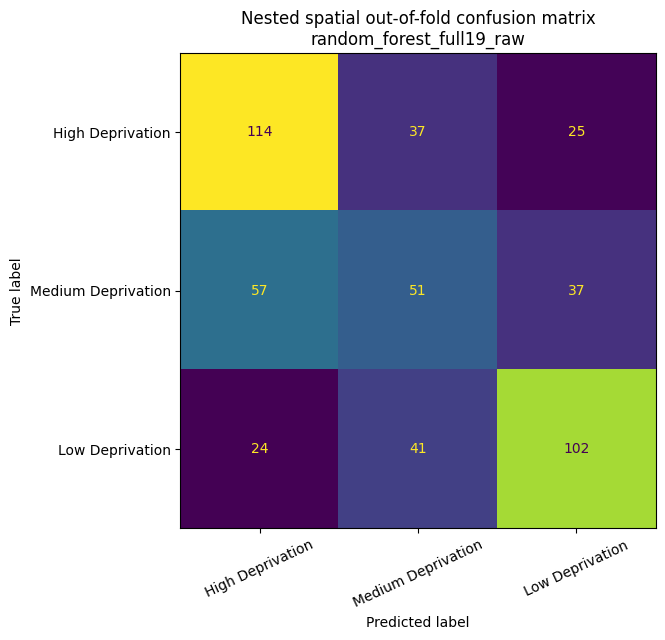

Saved diagnostics-ready OOF table: <PROJECT_DIR>/outputs_10points_metadata_once/nested_spatial_modelling_grouped_vs_full19/selected_model_oof_spatial_diagnostics.csv
Saved confusion matrix: <PROJECT_DIR>/outputs_10points_metadata_once/nested_spatial_modelling_grouped_vs_full19/figures/selected_model_oof_confusion_matrix.png


In [10]:
best_oof = oof_predictions.loc[oof_predictions["model"] == best_model_name].copy()
best_oof = best_oof.set_index(LSOA_ID_COL).loc[df[LSOA_ID_COL]].reset_index()

if len(best_oof) != EXPECTED_N_ROWS or best_oof[LSOA_ID_COL].nunique() != EXPECTED_N_ROWS:
    raise AssertionError("Selected-model OOF predictions do not cover all 488 LSOAs exactly once.")

print(classification_report(
    best_oof["observed_idx"],
    best_oof["predicted_idx"],
    labels=np.arange(len(CLASS_ORDER)),
    target_names=CLASS_ORDER,
    digits=3,
    zero_division=0,
))

cm = confusion_matrix(
    best_oof["observed_idx"],
    best_oof["predicted_idx"],
    labels=np.arange(len(CLASS_ORDER)),
)
fig, ax = plt.subplots(figsize=(7.5, 6.5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_ORDER).plot(
    ax=ax, values_format="d", xticks_rotation=25, colorbar=False
)
ax.set_title(f"Nested spatial out-of-fold confusion matrix\n{best_model_name}")
plt.tight_layout()
plt.savefig(CONFUSION_MATRIX_PNG, dpi=300, bbox_inches="tight")
plt.show()

# Notebook 05 expects binary, confidence-sensitive, class-specific and
# proper-scoring error variables in this file.
best_oof.to_csv(OOF_SELECTED_DIAGNOSTICS_CSV, index=False)
print("Saved diagnostics-ready OOF table:", OOF_SELECTED_DIAGNOSTICS_CSV)
print("Saved confusion matrix:", CONFUSION_MATRIX_PNG)

## 10. Tune the selected candidate on all LSOAs and save the final fitted model

In [11]:
selected_spec = candidates[best_model_name]
selected_features = selected_spec["features"]
full_inner_cv = GroupKFold(n_splits=len(EXPECTED_FOLDS))

final_search = GridSearchCV(
    estimator=selected_spec["pipeline"],
    param_grid=selected_spec["grid"],
    scoring="f1_macro",
    cv=full_inner_cv,
    n_jobs=N_JOBS,
    refit=True,
    return_train_score=True,
    error_score="raise",
)
final_search.fit(
    df[selected_features],
    y,
    groups=outer_groups,
)

final_model = final_search.best_estimator_
joblib.dump(final_model, FINAL_MODEL_FILE)

final_tuning_results = pd.DataFrame(final_search.cv_results_)
final_tuning_results["model"] = best_model_name
final_tuning_results.to_csv(FINAL_TUNING_CSV, index=False)

metadata = {
    "selected_model": best_model_name,
    "selection_rule": "highest mean outer-fold macro-F1; balanced accuracy and log-loss used as secondary ordering",
    "feature_representation": selected_spec["representation"],
    "features": selected_features,
    "class_order": CLASS_ORDER,
    "best_full_data_params": final_search.best_params_,
    "best_full_data_inner_cv_macro_f1": float(final_search.best_score_),
    "random_state": RANDOM_STATE,
    "n_lsoa": int(len(df)),
    "spatial_folds": sorted(int(v) for v in EXPECTED_FOLDS),
    "oof_spatial_diagnostics_file": str(OOF_SELECTED_DIAGNOSTICS_CSV),
}
with open(FINAL_METADATA_JSON, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Final model:", best_model_name)
print("Best full-data parameters:", final_search.best_params_)
print("Saved:", FINAL_MODEL_FILE)
print("Saved:", FINAL_METADATA_JSON)

Final model: random_forest_full19_raw
Best full-data parameters: {'clf__class_weight': 'balanced', 'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5, 'clf__n_estimators': 600}
Saved: <PROJECT_DIR>/outputs_10points_metadata_once/nested_spatial_modelling_grouped_vs_full19/models/final_selected_model.joblib
Saved: <PROJECT_DIR>/outputs_10points_metadata_once/nested_spatial_modelling_grouped_vs_full19/models/final_selected_model_metadata.json


## 11. Multiclass SHAP analysis of the final refitted model

                   feature  mean_absolute_shap
4           seg_fence_mean            0.057951
7            seg_pole_mean            0.029127
13  seg_traffic_light_mean            0.027451
17     seg_vegetation_mean            0.025309
18           seg_wall_mean            0.019819
3             seg_car_mean            0.016358
15          seg_train_mean            0.016032
2             seg_bus_mean            0.012906
14   seg_traffic_sign_mean            0.012400
9            seg_road_mean            0.009494
10       seg_sidewalk_mean            0.006220
12        seg_terrain_mean            0.005069
0         seg_bicycle_mean            0.004632
6          seg_person_mean            0.004604
1        seg_building_mean            0.004276
11            seg_sky_mean            0.003453
5      seg_motorcycle_mean            0.003172
16          seg_truck_mean            0.002055
8           seg_rider_mean            0.001909

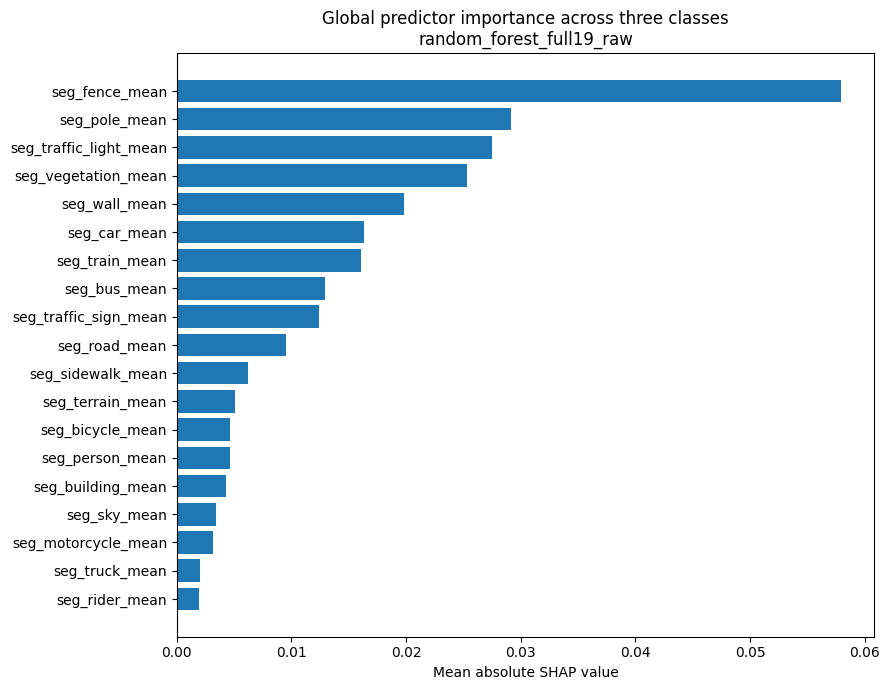

Saved: <PROJECT_DIR>/outputs_10points_metadata_once/nested_spatial_modelling_grouped_vs_full19/figures/final_shap_top20.png


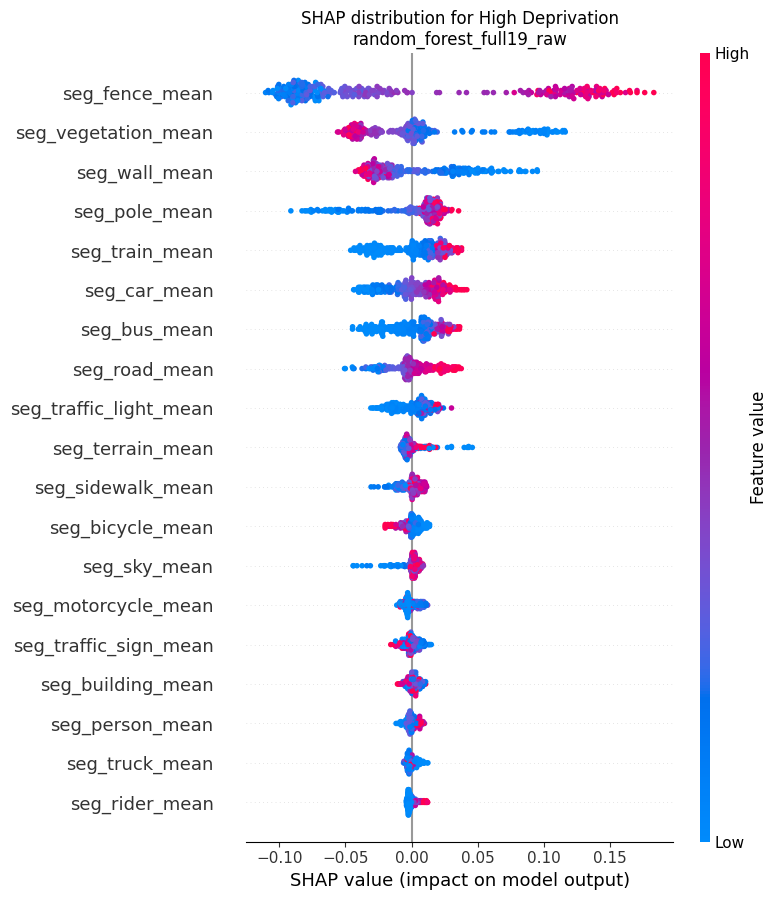

Saved: <PROJECT_DIR>/outputs_10points_metadata_once/nested_spatial_modelling_grouped_vs_full19/figures/final_shap_beeswarm_high_deprivation.png


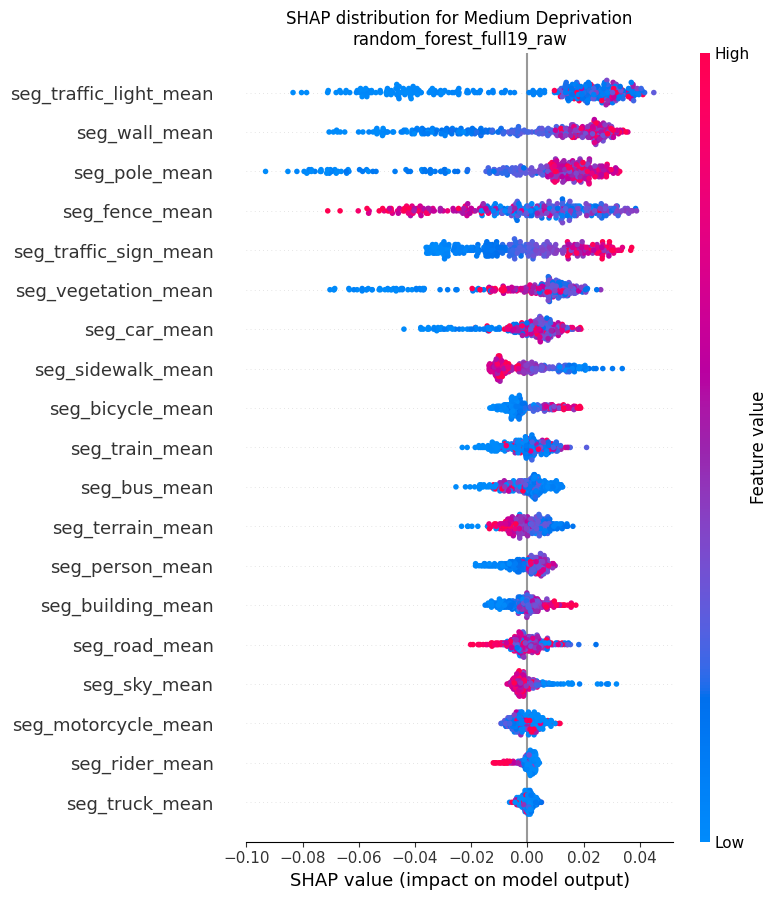

Saved: <PROJECT_DIR>/outputs_10points_metadata_once/nested_spatial_modelling_grouped_vs_full19/figures/final_shap_beeswarm_medium_deprivation.png


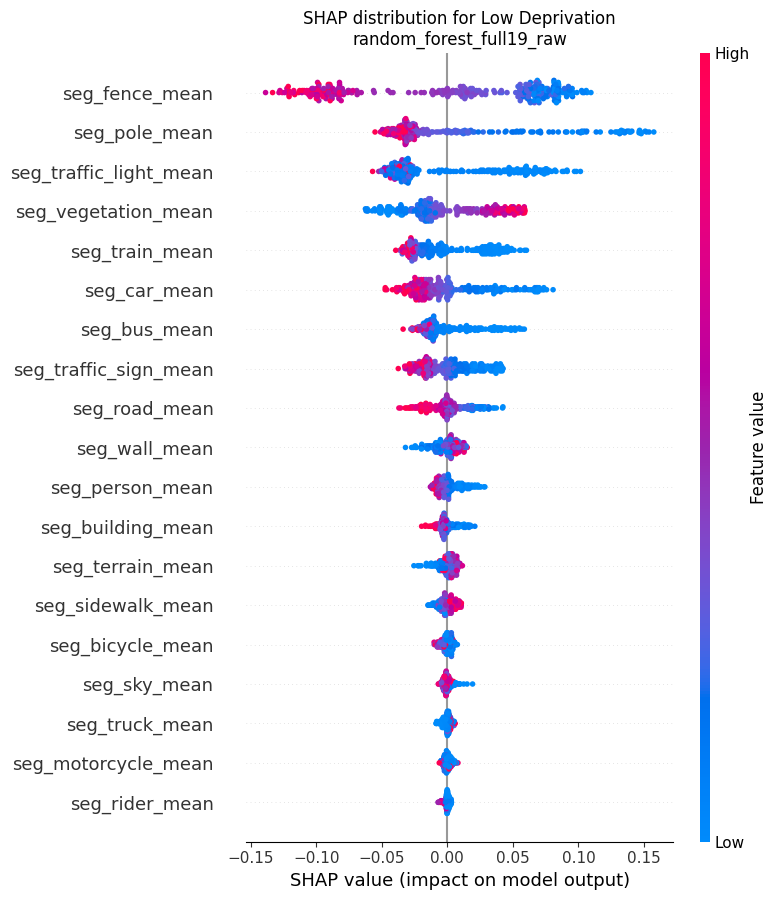

Saved: <PROJECT_DIR>/outputs_10points_metadata_once/nested_spatial_modelling_grouped_vs_full19/figures/final_shap_beeswarm_low_deprivation.png


In [12]:
def transformed_matrix_and_names(pipeline, X, original_names):
    preprocessor = pipeline[:-1]
    transformed = preprocessor.transform(X)
    transformed = np.asarray(transformed, dtype=float)

    names = list(original_names)
    if "clr" in pipeline.named_steps:
        names = [f"clr_{name}" for name in original_names]
    elif "ilr" in pipeline.named_steps:
        names = list(
            pipeline.named_steps["ilr"].get_feature_names_out(original_names)
        )
    if transformed.shape[1] != len(names):
        raise AssertionError("Transformed matrix and feature names disagree.")
    return transformed, names


def normalise_multiclass_shap(values, n_samples, n_features, n_classes):
    """Return SHAP array in (samples, features, classes) order."""
    if isinstance(values, list):
        arr = np.stack([np.asarray(v) for v in values], axis=-1)
    else:
        arr = np.asarray(values)

    if arr.ndim == 2:
        arr = arr[:, :, None]
    elif arr.ndim == 3:
        if arr.shape == (n_samples, n_features, n_classes):
            pass
        elif arr.shape == (n_classes, n_samples, n_features):
            arr = np.transpose(arr, (1, 2, 0))
        elif arr.shape == (n_samples, n_classes, n_features):
            arr = np.transpose(arr, (0, 2, 1))
        else:
            raise ValueError(f"Unrecognised multiclass SHAP shape: {arr.shape}")
    else:
        raise ValueError(f"Unrecognised SHAP dimensionality: {arr.shape}")

    return arr


X_explain = df[selected_features].copy()
if len(X_explain) > 300:
    X_explain = X_explain.sample(300, random_state=RANDOM_STATE)

X_transformed, transformed_feature_names = transformed_matrix_and_names(
    final_model, X_explain, selected_features
)
clf = final_model.named_steps["clf"]

background_size = min(100, len(X_transformed))
background = shap.sample(X_transformed, background_size, random_state=RANDOM_STATE)

if best_model_name.startswith("logistic"):
    explainer = shap.LinearExplainer(clf, background)
    raw_values = explainer.shap_values(X_transformed)
else:
    explainer = shap.TreeExplainer(clf)
    raw_values = explainer.shap_values(X_transformed)

shap_values = normalise_multiclass_shap(
    raw_values,
    n_samples=X_transformed.shape[0],
    n_features=X_transformed.shape[1],
    n_classes=len(CLASS_ORDER),
)

# Global magnitude: absolute values are averaged across samples and classes.
# Signed multiclass values are not averaged because opposite directions cancel.
global_importance = np.abs(shap_values).mean(axis=(0, 2))
importance = pd.DataFrame({
    "feature": transformed_feature_names,
    "mean_absolute_shap": global_importance,
}).sort_values("mean_absolute_shap", ascending=False)
importance.to_csv(SHAP_IMPORTANCE_CSV, index=False)
display(importance.head(20))

top = importance.head(20).sort_values("mean_absolute_shap")
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top["feature"], top["mean_absolute_shap"])
ax.set_xlabel("Mean absolute SHAP value")
ax.set_title(f"Global predictor importance across three classes\n{best_model_name}")
plt.tight_layout()
plt.savefig(SHAP_TOP20_PNG, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", SHAP_TOP20_PNG)

# Save one beeswarm per class. This preserves class direction and avoids
# incorrectly averaging signed values across the three outcomes.
for class_idx, class_label in enumerate(CLASS_ORDER):
    safe_label = class_label.lower().replace(" ", "_")
    class_path = FIGURE_DIR / f"final_shap_beeswarm_{safe_label}.png"
    shap.summary_plot(
        shap_values[:, :, class_idx],
        X_transformed,
        feature_names=transformed_feature_names,
        max_display=20,
        show=False,
    )
    plt.title(f"SHAP distribution for {class_label}\n{best_model_name}")
    plt.tight_layout()
    plt.savefig(class_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", class_path)

## 12. Output audit

In [13]:
expected_outputs = {
    "Outer-fold metrics": OUTER_METRICS_CSV,
    "OOF predictions for all candidates": OOF_ALL_MODELS_CSV,
    "Selected-model diagnostics export": OOF_SELECTED_DIAGNOSTICS_CSV,
    "Inner grid results": INNER_CV_RESULTS_CSV,
    "Model comparison": MODEL_COMPARISON_CSV,
    "Paired grouped-vs-full comparison": REPRESENTATION_COMPARISON_CSV,
    "Candidate manifest": MODELLING_DIR / "candidate_model_manifest.csv",
    "Final tuning results": FINAL_TUNING_CSV,
    "Final fitted model": FINAL_MODEL_FILE,
    "Final model metadata": FINAL_METADATA_JSON,
    "OOF confusion matrix": CONFUSION_MATRIX_PNG,
    "SHAP global importance": SHAP_IMPORTANCE_CSV,
    "SHAP top-20 plot": SHAP_TOP20_PNG,
}

audit = pd.DataFrame([
    {
        "output": label,
        "path": str(path),
        "exists": Path(path).exists(),
        "size_bytes": Path(path).stat().st_size if Path(path).exists() else np.nan,
    }
    for label, path in expected_outputs.items()
])
display(audit)
missing_outputs = audit.loc[~audit["exists"], "output"].tolist()
if missing_outputs:
    raise FileNotFoundError(f"Expected outputs were not created: {missing_outputs}")
print("Notebook 04 output audit passed.")

                                output  \
0                   Outer-fold metrics   
1   OOF predictions for all candidates   
2    Selected-model diagnostics export   
3                   Inner grid results   
4                     Model comparison   
5    Paired grouped-vs-full comparison   
6                   Candidate manifest   
7                 Final tuning results   
8                   Final fitted model   
9                 Final model metadata   
10                OOF confusion matrix   
11              SHAP global importance   
12                    SHAP top-20 plot   

                                                 path  exists  size_bytes  
0   <PROJECT_DIR>/outpu...    True        8960  
1   <PROJECT_DIR>/outpu...    True     1003509  
2   <PROJECT_DIR>/outpu...    True      168829  
3   <PROJECT_DIR>/outpu...    True      562229  
4   <PROJECT_DIR>/outpu...    True        2022  
5   <PROJECT_DIR>/outpu...    True        1283  
6   <PROJECT_DIR>/outpu...    True       

Notebook 04 output audit passed.


## Interpretation notes for Chapters 3 and 4

1. Treat the grouped and full representations as two explicitly compared feature-engineering strategies.
2. Compare the same algorithm across representations using the paired outer-fold table.
3. Report means and standard deviations across the five outer spatial folds.
4. The 19-part composition produces 18 ILR coordinates; this is expected, not feature deletion.
5. Random Forest and XGBoost use raw proportions as an algorithm-specific modelling choice.
6. A logistic-versus-tree comparison changes both classifier and preprocessing; do not attribute such a difference solely to the classifier.
7. SHAP for an ILR model describes log-ratio balances, not isolated effects of individual semantic classes.
8. Interpret SHAP as predictive association, not causation.
9. Keep `lsoa_spatial_plus_fold_mapping.csv` unchanged.
10. Run Moran's I, LISA and residual mapping only on the selected model's out-of-fold diagnostics export.
